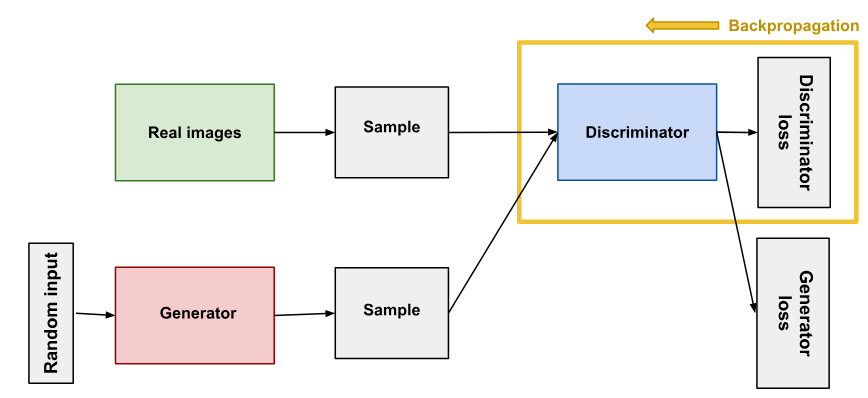

Generator and Discriminator are 2 different model, when trained they use 2 seperate loss. But looking at the architecture, Generator is depend on the Discriminator.

**During Discriminator training:**
1. D classifies both real and "fake data from the Generator".
2. D get penalizes through False Negative and True Negative (wrong prediction).
3. D updates using backprop from D's loss through D's network. 

However, the gradient flow from backprop starts at the output and flows back through the discriminator into the generator: `output -(gradient)-> discriminator -(gradient)-> generator` 

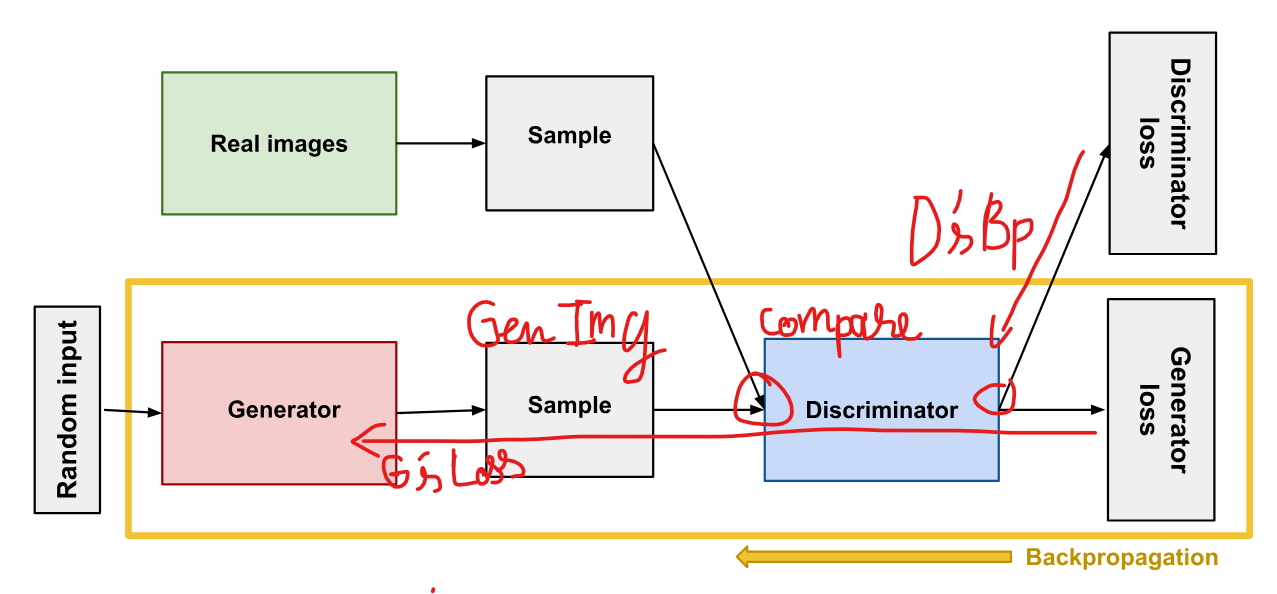
**During Generator training:**
1. Sample random noise
2. Produce generator output from sampled random noise
3. Evaluation: Get Discriminator "Real" or "Fake" label for Generator Output
4. Calculate loss from discriminator classification.
5. Get Gradient by backprop through Discriminator and Generator. 
6. Use that gradient to update Generator weights

**Becuase GAN have 2 seperately model, its training algo must address 2 difficulty:**
+ GAN changing between 2 different kinds of training (Generator and Discriminator)
+ GAN convergence is hard to identify ? 

**During GAN training,** if the Discriminator update along with the Generator it would be like trying to hit a moving target and might never converge. So Discriminator's frozen during Generator training and in reverse for during Discriminator training. So GAN training in alternating periods:
1. The Discriminator trains for 1 or more epochs
2. The generator trains for 1 or more epochs
3. Repeat steps 1 and 2 until training finish for Generator and Discriminator networks.

Note: if the Discriminator can't classifies what Real and Fake you can't get GAN training started.

**Convergence** achieved when the Discriminator can't easily tell the different between real and fake -> The Discriminator has a 50% accuracy (like flips a coin for prediction)

**Problem in Training Progress** as a whole, as training go on, the D's feedback get less meaningful over time. If GAN continuous training past the point when the D is gobing completely random 50-50 feedback, then the generator starts to train on junk feedback making its own quality may collapse.

For a GAN, convergence is often a fleeting, rather than stable, state.


### GAN's Loss Function
GAN's try to replicate a prob distribution -> Need a Loss func to reflect the distance between the distribution of generated data by GAN and the distribution of real data.

**Minmax Loss**
MinMax here mean 1 function trying to Minimize the Loss (Generator) while the other function try to Maximize the Loss other function (Discriminator). 

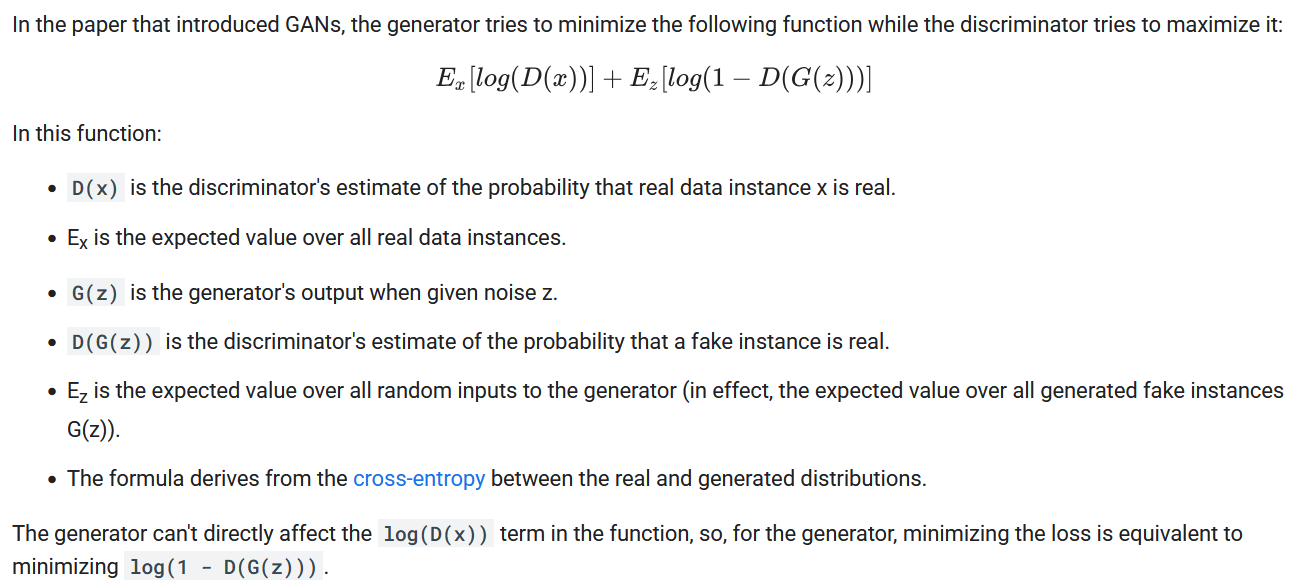
This loss func is base on Cross-Entropy so the **gradients that used to train the generator can vanish** if the generator's fake samples are very far away from the real input. 

**Note:** Cross-Entropy return 0:Fake or 1:Realm without telling "how different" the 2 images are.
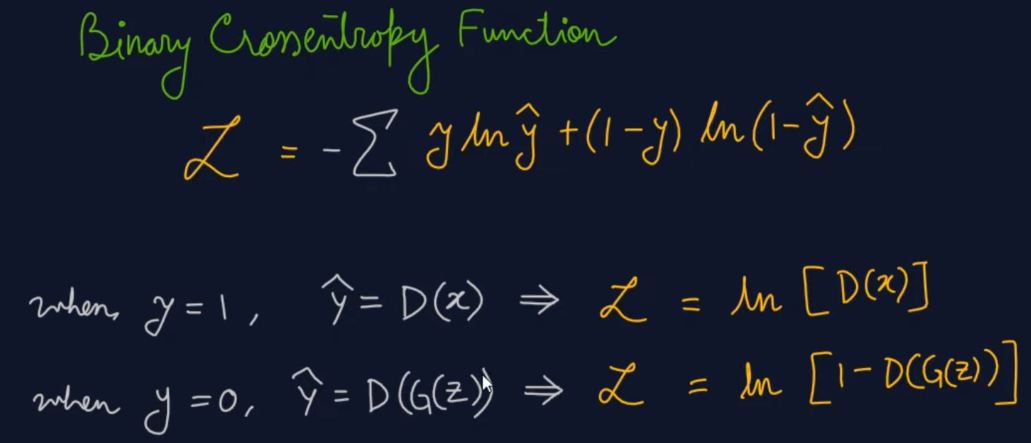

-> Vanishing Gradient mean no Feedback, no feed back mean the model don't know what/where to improve.

That where **Wasserstain Loss** come in, instead of saying True/False, its response extractly how far between the 2 distribution. 
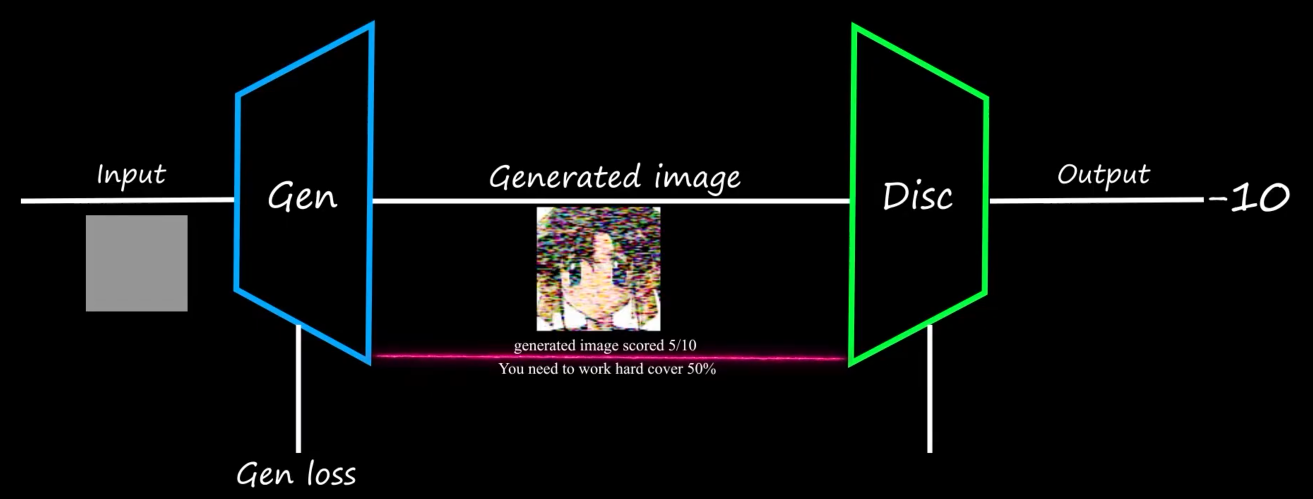

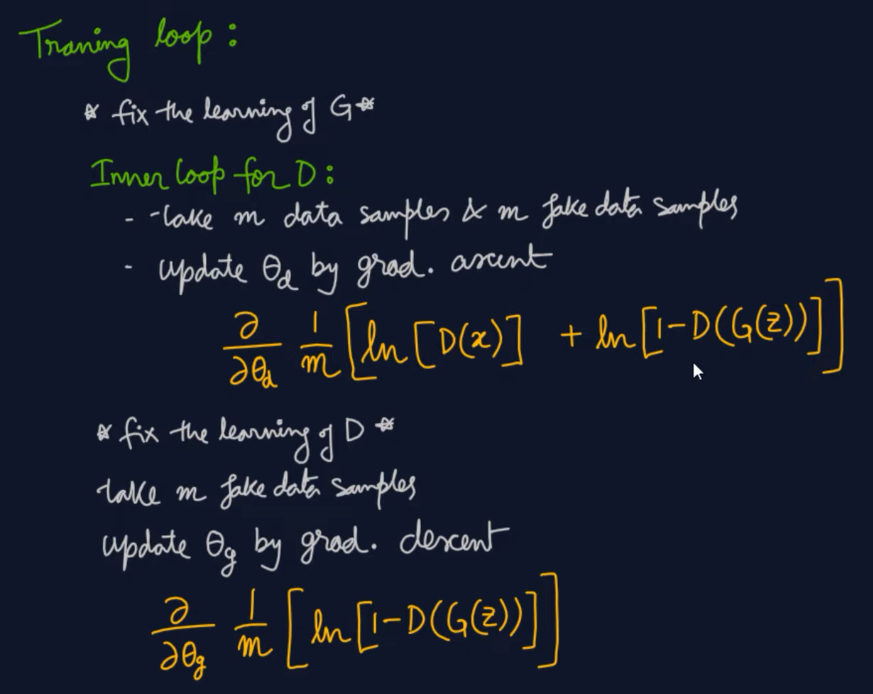
p_g = p_data at global minimum

In [60]:
import torch
from torch import nn
from torchvision import datasets, transforms
import numpy as np

# define GAN input noise
latent_dim = 512
img_size = 1
channels = 100
img_shape = (channels, img_size, img_size)
flat_size = int(np.prod(img_shape))  # 784

In [61]:
z = torch.randn((img_shape))
z.shape

torch.Size([100, 1, 1])

In [62]:
def conv_transpose_output_size(h_in, kernel, stride, padding, output_padding=0):
    """
    Calculate output size of ConvTranspose2d layer.

    Formula: H_out = (H_in - 1) × stride - 2 × padding + kernel_size + output_padding
    """
    h_out = (h_in - 1) * stride - 2 * padding + kernel + output_padding
    return h_out

out_size = conv_transpose_output_size(4, 5, 2, 1) # 4 -> 9
out_size = conv_transpose_output_size(out_size, 4, 2, 1)
out_size = conv_transpose_output_size(out_size, 4, 2, 1)
out_size

36

In [63]:
import numpy as np

x_real = np.array([0.9, 0.8])
x_fake = np.array([0.2, 0.1])
L_d = -1/2 * (np.log(x_real[0]) + np.log(x_real[1]) + np.log(1 - x_fake[0]) + np.log(1 - x_fake[1]))
L_g = -1/2 * (np.log(x_fake[1]) + np.log(x_fake[0]))

print(round(L_d, 4), round(L_g, 4))

0.3285 1.956


In [64]:
fake_prob = 0.2
real_prob = 0.9
# D(G(z|y)|y) = 0.2
# D(x|y)=0.9
# y = 0
gen_loss = -np.log(fake_prob)
y = 1
real_loss = -y*np.log(real_prob) - (1-y)*np.log(1-fake_prob)
y = 0
fake_loss = -y*np.log(real_prob) - (1-y)*np.log(1-fake_prob)

dis_loss = (real_loss + fake_loss) / 2
print(round(gen_loss, 3), round(dis_loss, 3))

1.609 0.164


In [65]:
# class Generator(nn.Module):
#     def __init__(self, *args, **kwargs) -> None:
#         super().__init__(*args, **kwargs)
#         self.linear = nn.Sequential(
#             nn.Linear(img_size, 256),
#             nn.ReLU(),

#         )

#         # self.expand_z = nn.ConvTranspose2d(
#         #     in_channels=100,
#         #     out_channels=256,
#         #     kernel_size=4,
#         #     stride=1,
#         #     padding=0
#         # )

#         self.conv_tranpose = nn.Sequential(
#             nn.ConvTranspose2d(256, 128, 5, 2, 1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),

#             nn.ConvTranspose2d(128, 64, 4, 2, 1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),

#             nn.ConvTranspose2d(64, 3, 4, 2, 1),
#             nn.BatchNorm2d(3),
#             nn.ReLU(),
#         )

#     def forward(self, x):
#         return x

class Generator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linear = nn.Sequential(
            # take in flatten input
            nn.Linear(100, 256*4*4),
            nn.ReLU(),

        )

        self.convolution = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
        )


    def forward(self, x):
        x = x.flatten().unsqueeze(0)
        x = self.linear(x) # input_dim -> (256, 4, 4)
        x = x.view(x.size(0), 256, 4, 4)

        x = self.convolution(x)
        return x


generator = Generator()
generator(z).shape # B, C, H, W

torch.Size([1, 3, 36, 36])

In [66]:
# import torch
# import torch.nn as nn

# class Generator(nn.Module):
#     def __init__(self):
#         super(Generator, self).__init__()

#         # 1. Linear -> Reshape -> ReLU
#         # Project 100-dim vector to 4096-dim (256 * 4 * 4)
#         self.linear_block = nn.Sequential(
#             nn.Linear(in_features=100, out_features=256 * 4 * 4),
#             nn.ReLU() # Note: Diagram places ReLU after Reshape, but mathematically it's identical here
#         )

#         # 2. Convolutional Blocks
#         self.conv_blocks = nn.Sequential(
#             # Block 1: Output size -> (128, 9, 9)
#             nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),

#             # Block 2: Output size -> (64, 18, 18)
#             nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),

#             # Block 3: Output size -> (3, 36, 36)
#             nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
#             nn.Tanh()
#         )

#     def forward(self, z):
#         # Flatten noise vector (Batch, 100, 1, 1) -> (Batch, 100)
#         z = z.view(z.size(0), -1)

#         # Pass through Linear and ReLU
#         x = self.linear_block(z)

#         # Reshape to (Batch, Channels, Height, Width)
#         x = x.view(-1, 256, 4, 4)

#         # Pass through ConvTranspose blocks
#         x = self.conv_blocks(x)

#         return x

# # Validation
# generator = Generator()
# noise = torch.randn(1, 100, 1, 1)
# output = generator(noise)
# print(f"Final output shape matches diagram: {output.shape}")
# # Expected: torch.Size([1, 3, 36, 36])

## Pix2Pix (Conditional GAN)
L_adv - Adversarial Loss

In [67]:
import numpy as np

# 1. Define the data batches
# Domain X
X = np.array([[2, 1, 3],
            [0, 4, 1]])
F_G_X = np.array([[1, 1, 2],
                [2, 3, 1]])

# Domain Y
Y = np.array([[3, 1, 0],
            [2, 2, 2]])
G_F_Y = np.array([[2, 1, 1],
                [1, 1, 1]])

# 2. Calculate L1 norms (sum of absolute differences for each vector)
# axis=1 calculates the sum across the elements of each individual vector
norm_X = np.sum(np.abs(F_G_X - X), axis=1) # Output: [2, 3]
norm_Y = np.sum(np.abs(G_F_Y - Y), axis=1) # Output: [2, 3]

# 3. Apply the formula: 1/2 * sum(L1_norms)
loss_X = 0.5 * np.sum(norm_X)
loss_Y = 0.5 * np.sum(norm_Y)

# Total Cycle Consistency Loss
L_cyc = loss_X + loss_Y

print(f"Loss X: {loss_X}")
print(f"Loss Y: {loss_Y}")
print(f"Total L_cyc: {L_cyc}")

Loss X: 2.5
Loss Y: 2.5
Total L_cyc: 5.0
